(sec-qml-top)=

<div align="center">
    <h1>Hybrid Quantum Neural Networks</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/PU_CHE597_DSinChemE/blob/main/22-Quantum_Machine_Learning/hybrid_qnns.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

# Hybrid Quantum Neural Networks
## Table of Contents
- [Lecture Overview](#sec-qml-overview)
- [QNN Basics](#sec-qml-basics)
- [Environment Setup](#sec-qml-setup)
- [Data Preparation](#sec-qml-data)
- [Hybrid Model](#sec-qml-model)
- [Why This Ansatz?](#sec-qml-ansatz)
- [Loss Function](#sec-qml-loss)
- [Circuit Intuition (1, 2, and 4 Qubits)](#sec-qml-circuit-intuition)
- [Network Visualization](#sec-qml-visualization)
- [CPU Run](#sec-qml-cpu)
- [GPU Run](#sec-qml-gpu)
- [Classical Parameter-Matched Baseline](#sec-qml-classical)
- [Performance Comparison](#sec-qml-compare)
- [Is This Dataset Too Easy?](#sec-qml-difficulty)
- [Qubit Scaling Study](#sec-qml-scaling)
- [References](#sec-qml-references)

(sec-qml-overview)=
## Lecture Overview

This lecture introduces a **hybrid quantum neural network (QNN)** workflow using CUDA-Q and PyTorch for binary classification on MNIST digits.

**Original source tutorial (acknowledged):**
- NVIDIA CUDA-Q tutorial: [Hybrid QNNs](https://nvidia.github.io/cuda-quantum/0.8.0/examples/python/tutorials/hybrid_qnns.html)

This notebook adapts the tutorial into CHE 597 lecture format and adds:
- a course-standard header and links,
- Colab-compatible setup cells,
- separate CPU and GPU runs,
- simple circuit-level explanations for 1 and 2 qubits,
- qubit-count scaling experiments with baseline result reuse.

(sec-qml-basics)=
## QNN Basics

A **quantum neural network (QNN)** here means:
- a classical network computes numbers,
- those numbers become angles in a quantum circuit,
- the circuit returns expectation values,
- training updates angles to improve prediction accuracy.

### What Is A Qubit?

A classical bit can only be `0` or `1`. A qubit can be in a **superposition** of both basis states:

$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle, \quad \alpha,\beta \in \mathbb{C}, \quad |\alpha|^2 + |\beta|^2 = 1$

Basis vectors are:

$|0\rangle = \begin{bmatrix}1\\0\end{bmatrix}, \qquad |1\rangle = \begin{bmatrix}0\\1\end{bmatrix}$

Interpretation:
- measuring the qubit gives `0` with probability $|\alpha|^2$,
- measuring the qubit gives `1` with probability $|\beta|^2$.

### Parameterized Rotation Gates

In this notebook, each qubit is transformed by two parameterized single-qubit rotations:

$R_x(\theta)=\begin{bmatrix}
\cos(\theta/2) & -i\sin(\theta/2)\\
-i\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}$

$R_y(\theta)=\begin{bmatrix}
\cos(\theta/2) & -\sin(\theta/2)\\
\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}$

The angle $\theta$ is trainable. So these are "learnable quantum gates":
- changing $\theta$ changes the quantum state,
- that changes measurement outcomes,
- gradients update $\theta$ during training.

For `q` qubits, this ansatz uses `2q` rotation angles:
- 1 qubit -> 2 angles (`\theta_0`, `\theta_1`),
- 2 qubits -> 4 angles (`\theta_0`, `\theta_1`, `\theta_2`, `\theta_3`),
- 4 qubits -> 8 angles.

### Why This Matters For Hybrid Learning

The classical trunk outputs these rotation angles. The quantum circuit then maps them to expectation values.
So the quantum block is part of the end-to-end differentiable model, just like a classical layer.

In [1]:
# Detect whether we are running in Google Colab.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = True


(sec-qml-setup)=
## Environment Setup

For local execution, activate your course environment before launching Jupyter:

```bash
conda activate PU-DSinChemE
```

For Google Colab:
1. Open this notebook with the **Open in Colab** badge.
2. Select `Runtime -> Change runtime type -> GPU` if you want GPU acceleration.
3. Run the setup cell below first.

Runtime reproducibility note:
- each benchmark run reports CPU/GPU hardware details,
- hardware labels are included in printed summaries and runtime plots.

In [2]:
import importlib.util
import subprocess
import sys

AUTO_INSTALL_MISSING_LOCAL = True
INSTALL_PINNED_IN_COLAB = False  # Safer default for evolving Colab Python runtimes.
ALLOW_CLASSICAL_FALLBACK_IF_CUDAQ_UNAVAILABLE = True

required_packages = {
    "cudaq": "cuda-quantum==0.8.0",
    "torch": "torch==2.2.2",
    "torchvision": "torchvision==0.17.0",
    "sklearn": "scikit-learn==1.4.2",
    "matplotlib": "matplotlib==3.8.4",
}


def module_missing(module_name):
    return importlib.util.find_spec(module_name) is None


def pip_install(specs, extra_index_url=None):
    cmd = [sys.executable, "-m", "pip", "install"]
    if extra_index_url:
        cmd.extend(["--extra-index-url", extra_index_url])
    cmd.extend(specs)
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)


def try_install_with_fallbacks(spec):
    # First try standard PyPI, then NVIDIA index fallback.
    try:
        pip_install([spec])
        return True
    except subprocess.CalledProcessError as exc:
        print(f"Failed installing {spec} from default index (exit code {exc.returncode}).")

    try:
        pip_install([spec], extra_index_url="https://pypi.nvidia.com")
        return True
    except subprocess.CalledProcessError as exc:
        print(f"Failed installing {spec} from NVIDIA index (exit code {exc.returncode}).")
        return False


if IN_COLAB:
    py_ver = f"{sys.version_info.major}.{sys.version_info.minor}"
    print(f"Detected Colab Python {py_ver}")

    if INSTALL_PINNED_IN_COLAB and sys.version_info[:2] <= (3, 10):
        print("Installing pinned packages for Colab runtime...")
        pip_install(list(required_packages.values()))
    else:
        # Compatibility-first installation for newer Colab runtimes (e.g., Python 3.11/3.12).
        candidate_specs = {
            "cudaq": ["cuda-quantum", "cudaq", "cuda-quantum==0.8.0"],
            "torch": ["torch"],
            "torchvision": ["torchvision"],
            "sklearn": ["scikit-learn"],
            "matplotlib": ["matplotlib"],
        }

        missing_modules = [m for m in required_packages if module_missing(m)]

        if not missing_modules:
            print("All required packages are already available in Colab.")
        else:
            print("Missing packages in Colab:", ", ".join(missing_modules))
            for module in missing_modules:
                installed = False
                for spec in candidate_specs[module]:
                    print(f"Attempting install for {module}: {spec}")
                    if try_install_with_fallbacks(spec):
                        installed = True
                        break

                if not installed:
                    if module == "cudaq" and ALLOW_CLASSICAL_FALLBACK_IF_CUDAQ_UNAVAILABLE:
                        print(
                            "WARNING: CUDA-Q could not be installed in this Colab runtime. "
                            "Quantum sections will be skipped, but classical sections can still run."
                        )
                    else:
                        raise RuntimeError(
                            f"Could not install dependency for '{module}' on Python {py_ver}. "
                            "Try installing manually in Colab and then rerun this notebook."
                        )
else:
    missing_specs = [
        spec for module, spec in required_packages.items()
        if module_missing(module)
    ]

    if missing_specs:
        print("Missing packages detected:")
        for spec in missing_specs:
            print(f" - {spec}")

        if AUTO_INSTALL_MISSING_LOCAL:
            print("Installing missing packages...")
            pip_install(missing_specs)
        else:
            raise ImportError(
                "Install required packages manually, or set AUTO_INSTALL_MISSING_LOCAL = True."
            )
    else:
        print("All required packages are already installed.")

CUDAQ_AVAILABLE = not module_missing("cudaq")
print(f"CUDAQ_AVAILABLE = {CUDAQ_AVAILABLE}")

if IN_COLAB:
    print("Colab note: choose a GPU runtime before running the GPU and sweep sections.")
    print("If packages were installed, rerun the import/setup cells below.")

Detected Colab Python 3.12
Missing packages in Colab: cudaq
Attempting install for cudaq: cuda-quantum
Running: /usr/bin/python3 -m pip install cuda-quantum
Failed installing cuda-quantum from default index (exit code 1).
Running: /usr/bin/python3 -m pip install --extra-index-url https://pypi.nvidia.com cuda-quantum
Failed installing cuda-quantum from NVIDIA index (exit code 1).
Attempting install for cudaq: cudaq
Running: /usr/bin/python3 -m pip install cudaq
CUDAQ_AVAILABLE = True
Colab note: choose a GPU runtime before running the GPU and sweep sections.
If packages were installed, rerun the import/setup cells below.


In [3]:
import importlib.util
import platform
import subprocess
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from torch.autograd import Function
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets
from sklearn.model_selection import train_test_split

if importlib.util.find_spec("cudaq") is not None:
    import cudaq
    from cudaq import spin
    CUDAQ_AVAILABLE = True
else:
    cudaq = None
    spin = None
    CUDAQ_AVAILABLE = False

torch.manual_seed(22)
np.random.seed(22)
if CUDAQ_AVAILABLE:
    cudaq.set_random_seed(44)

print("torch version:", torch.__version__)
if CUDAQ_AVAILABLE:
    print("cudaq version:", cudaq.__version__)
else:
    print("cudaq version: unavailable in this runtime")
    print("Quantum sections will be skipped unless CUDA-Q is installed.")

torch version: 2.10.0+cu128
cudaq version: CUDA-Q Version 0.13.0 (https://github.com/NVIDIA/cuda-quantum b66c5bb7fd8c08e5014e2f03e97e7b0e92691650)


(sec-qml-data)=
## Data Preparation

In [4]:
# Classical parameters.
SAMPLE_COUNT = 400  # Increase to 1000+ for more demanding experiments.
TARGET_DIGITS = [5, 6]
TEST_SIZE = 30
CLASSIFICATION_THRESHOLD = 0.5

# More epochs than the initial draft to show stable convergence trends.
EPOCHS = 80
SWEEP_EPOCHS = EPOCHS  # Match baseline epochs so reused q=1 result is directly comparable.
LEARNING_RATE = 0.005
WEIGHT_DECAY = 0.0
LOG_EVERY = 20

# Quantum parameters.
QUBIT_COUNT = 1
QUBIT_VALUES_TO_TEST = [1, 2, 4]
RUN_GPU_SWEEP = True  # Set to True to include GPU qubit sweep.
SHIFT_MAGNITUDE = np.pi / 2

MNIST_ROOT = Path.home() / ".cache" / "che597_mnist"
MNIST_ROOT.mkdir(parents=True, exist_ok=True)


In [5]:


def prepare_data(target_digits, sample_count, test_size):
    dataset = datasets.MNIST(str(MNIST_ROOT), train=True, download=True)

    idx = (dataset.targets == target_digits[0]) | (dataset.targets == target_digits[1])
    x = dataset.data[idx].float().unsqueeze(1) / 255.0
    y = dataset.targets[idx].float()

    subset_indices = torch.randperm(x.size(0))[:sample_count]
    x = x[subset_indices]
    y = y[subset_indices]
    y = torch.where(y == min(target_digits), 0.0, 1.0)

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size / 100,
        shuffle=True,
        random_state=42,
        stratify=y,
    )

    return x_train, x_test, y_train, y_test


x_train_cpu, x_test_cpu, y_train_cpu, y_test_cpu = prepare_data(
    TARGET_DIGITS,
    SAMPLE_COUNT,
    TEST_SIZE,
)

print("x_train shape:", tuple(x_train_cpu.shape))
print("x_test shape:", tuple(x_test_cpu.shape))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.89MB/s]

x_train shape: (280, 1, 28, 28)
x_test shape: (120, 1, 28, 28)


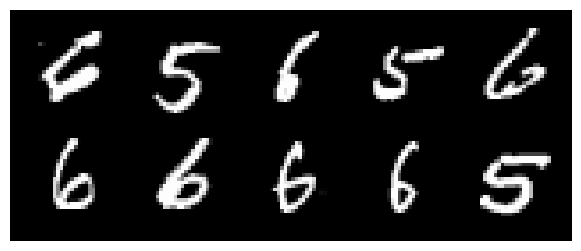

In [6]:
# Plot a few images from the training split.
grid_img = torchvision.utils.make_grid(
    x_train_cpu[:10],
    nrow=5,
    padding=3,
    normalize=True,
)

plt.figure(figsize=(8, 3))
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis("off")
plt.show()

(sec-qml-model)=
## Hybrid Model

The model has two blocks:
1. **Classical block** (fully connected layers) that maps image pixels to a compact feature vector.
2. **Quantum block** that interprets that vector as rotation angles for the quantum circuit.

For `qubit_count = q`:
- the classical block outputs `2q` values,
- these values drive `Ry` and `Rx` rotations on each qubit,
- an entangling chain of CNOT gates links neighboring qubits,
- we measure an averaged Z expectation as the quantum-layer output.

We also include a **classical parameter-matched baseline**:
- replace the quantum layer with a classical linear head that has `2q` trainable parameters,
- this helps compare whether gains come from the quantum map itself or from model capacity.

During backpropagation, gradients of quantum parameters are computed with a parameter-shift finite-difference rule.

(sec-qml-ansatz)=
## Why This Ansatz?

This is a good question. The ansatz in this lecture is intentionally simple:
- one `Ry` and one `Rx` rotation per qubit,
- one nearest-neighbor entangling chain.

Why we chose it:
- **Pedagogical clarity:** easy to map from classical outputs (`2q` numbers) to circuit parameters.
- **Stable runtime for class use:** parameter count scales linearly (`2q`) and is practical for sweeps.
- **Hardware-aware structure:** local rotations + nearest-neighbor CNOTs are a common NISQ-friendly starting point.

**Note:** this ansatz is a baseline, not a unique or universally optimal choice.
Alternative ansätze can be stronger but more expensive (extra layers, data re-uploading, denser entanglement, different gate sets).

Mini-exercise: add a second entangling layer and compare runtime/accuracy versus the default ansatz.

(sec-qml-loss)=
## Loss Function

The training curves use **binary cross-entropy (BCE)** loss:

$L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$

where:
- $y_i \in \{0,1\}$ is the true label,
- $\hat{y}_i = \sigma(z_i)$ is the predicted probability after sigmoid.

So the left plot shows **BCE loss** (not a generic/undefined "cost").
Accuracy is computed separately using `CLASSIFICATION_THRESHOLD = 0.5`.

In [7]:
def build_hamiltonian(qubit_count):
    if not CUDAQ_AVAILABLE:
        raise RuntimeError("CUDA-Q is unavailable in this runtime; cannot build quantum Hamiltonian.")

    hamiltonian = spin.z(0)
    for q in range(1, qubit_count):
        hamiltonian = hamiltonian + spin.z(q)
    return (1.0 / qubit_count) * hamiltonian


def read_cpu_name():
    try:
        with open("/proc/cpuinfo", "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                if "model name" in line:
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass

    return (platform.processor() or platform.machine() or "unknown-cpu").strip()


def read_gpu_name(device):
    if device.type == "cuda" and torch.cuda.is_available():
        idx = 0 if device.index is None else device.index
        try:
            return torch.cuda.get_device_name(idx)
        except Exception:
            pass

    try:
        output = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            text=True,
        ).strip().splitlines()
        if output:
            return output[0].strip()
    except Exception:
        pass

    return "none"


def compact_name(name, max_chars=36):
    name = str(name).strip()
    if len(name) <= max_chars:
        return name
    return name[: max_chars - 3] + "..."


def hardware_strings(device):
    cpu_name = read_cpu_name()
    gpu_name = read_gpu_name(device) if device.type == "cuda" else "none"

    if device.type == "cuda" and gpu_name != "none":
        short = f"GPU: {compact_name(gpu_name, 34)}"
        full = f"CPU={cpu_name} | GPU={gpu_name}"
    else:
        short = f"CPU: {compact_name(cpu_name, 34)}"
        full = f"CPU={cpu_name}"

    return cpu_name, gpu_name, short, full


class QuantumCircuitBackend:
    # CUDA-Q circuit wrapper used inside a PyTorch autograd function.
    def __init__(self, qubit_count, hamiltonian, device):
        @cudaq.kernel
        def kernel(qubit_count: int, thetas: np.ndarray):
            qubits = cudaq.qvector(qubit_count)

            for q in range(qubit_count):
                ry(thetas[2 * q], qubits[q])
                rx(thetas[2 * q + 1], qubits[q])

            for q in range(qubit_count - 1):
                x.ctrl(qubits[q], qubits[q + 1])

        self.kernel = kernel
        self.qubit_count = qubit_count
        self.hamiltonian = hamiltonian
        self.device = device

    def run(self, theta_vals):
        qubit_count = [self.qubit_count for _ in range(theta_vals.shape[0])]
        results = cudaq.observe(self.kernel, self.hamiltonian, qubit_count, theta_vals)
        exp_vals = [results[i].expectation() for i in range(len(results))]
        return torch.tensor(exp_vals, dtype=torch.float32, device=self.device)


class QuantumFunction(Function):
    @staticmethod
    def forward(ctx, thetas, quantum_backend, shift):
        ctx.quantum_backend = quantum_backend
        ctx.shift = shift
        exp_vals = ctx.quantum_backend.run(thetas).reshape(-1, 1)
        ctx.save_for_backward(thetas)
        return exp_vals

    @staticmethod
    def backward(ctx, grad_output):
        (thetas,) = ctx.saved_tensors
        gradients = torch.zeros_like(thetas)

        for i in range(thetas.shape[1]):
            thetas_plus = thetas.clone()
            thetas_plus[:, i] += ctx.shift
            exp_vals_plus = ctx.quantum_backend.run(thetas_plus)

            thetas_minus = thetas.clone()
            thetas_minus[:, i] -= ctx.shift
            exp_vals_minus = ctx.quantum_backend.run(thetas_minus)

            gradients[:, i] = (exp_vals_plus - exp_vals_minus) / (2 * ctx.shift)

        gradients = grad_output * gradients
        return gradients, None, None


class QuantumLayer(nn.Module):
    def __init__(self, qubit_count, hamiltonian, shift, device):
        super().__init__()
        self.quantum_backend = QuantumCircuitBackend(qubit_count, hamiltonian, device)
        self.shift = torch.tensor(shift, dtype=torch.float32, device=device)

    def forward(self, input_tensor):
        return QuantumFunction.apply(input_tensor, self.quantum_backend, self.shift)


class ClassicalMatchedLayer(nn.Module):
    # Parameter-matched classical replacement: exactly 2q trainable weights.
    def __init__(self, qubit_count):
        super().__init__()
        self.weights = nn.Parameter(torch.empty(2 * qubit_count))
        nn.init.normal_(self.weights, mean=0.0, std=0.1)

    def forward(self, input_tensor):
        # Centering allows signed logits with the same number of trainable parameters.
        centered = input_tensor - input_tensor.mean(dim=1, keepdim=True)
        return torch.matmul(centered, self.weights.unsqueeze(1))


class HybridTrunk(nn.Module):
    def __init__(self, qubit_count, use_final_relu=True):
        super().__init__()
        quantum_params = 2 * qubit_count
        self.use_final_relu = use_final_relu

        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, quantum_params)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)

        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        if self.use_final_relu:
            x = torch.relu(x)
        x = self.dropout(x)
        return x


class HybridQuantumQNN(nn.Module):
    def __init__(self, qubit_count, hamiltonian, shift, device):
        super().__init__()
        self.trunk = HybridTrunk(qubit_count, use_final_relu=True)
        self.quantum = QuantumLayer(qubit_count, hamiltonian, shift, device)

    def forward(self, x):
        x = self.trunk(x)
        x = torch.sigmoid(self.quantum(x))
        return x.view(-1)


class HybridClassicalBaseline(nn.Module):
    def __init__(self, qubit_count):
        super().__init__()
        # Use signed features before the classical matched head.
        self.trunk = HybridTrunk(qubit_count, use_final_relu=False)
        self.classical_head = ClassicalMatchedLayer(qubit_count)

    def forward(self, x):
        x = self.trunk(x)
        x = torch.sigmoid(self.classical_head(x))
        return x.view(-1)


def accuracy_score(y_true, y_pred, threshold=CLASSIFICATION_THRESHOLD):
    return (y_true == (y_pred >= threshold)).float().mean().item()


def count_trainable_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


@dataclass
class RunResult:
    label: str
    model_type: str
    cudaq_target: str
    device_name: str
    cpu_name: str
    gpu_name: str
    hardware_short: str
    hardware_full: str
    qubit_count: int
    elapsed_s: float
    trainable_params_total: int
    trainable_params_trunk: int
    trainable_params_head: int
    final_train_cost: float
    final_test_cost: float
    final_train_accuracy: float
    final_test_accuracy: float
    training_cost: list
    testing_cost: list
    training_accuracy: list
    testing_accuracy: list

In [8]:
def run_training(
    label,
    torch_device,
    qubit_count=QUBIT_COUNT,
    epochs=EPOCHS,
    log_every=LOG_EVERY,
    seed=22,
    model_type="quantum",
    cudaq_target="qpp-cpu",
):
    device = torch.device(torch_device)

    cpu_name, gpu_name, hardware_short, hardware_full = hardware_strings(device)

    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if CUDAQ_AVAILABLE:
        cudaq.set_random_seed(seed + 22)

    if device.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("torch.cuda.is_available() is False on this machine.")

    hamiltonian = None
    if model_type == "quantum":
        if not CUDAQ_AVAILABLE:
            raise RuntimeError("CUDA-Q is unavailable in this runtime. Install CUDA-Q or use a compatible runtime for quantum sections.")

        if hasattr(cudaq, "reset_target"):
            try:
                cudaq.reset_target()
            except Exception:
                pass

        cudaq.set_target(cudaq_target)
        hamiltonian = build_hamiltonian(qubit_count)
    elif model_type == "classical":
        cudaq_target = "none"
    else:
        raise ValueError(f"Unsupported model_type={model_type!r}. Use 'quantum' or 'classical'.")

    x_train = x_train_cpu.to(device)
    x_test = x_test_cpu.to(device)
    y_train = y_train_cpu.to(device)
    y_test = y_test_cpu.to(device)

    if model_type == "quantum":
        model = HybridQuantumQNN(qubit_count, hamiltonian, SHIFT_MAGNITUDE, device).to(device)
        head_params = count_trainable_params(model.quantum)
    else:
        model = HybridClassicalBaseline(qubit_count).to(device)
        head_params = count_trainable_params(model.classical_head)

    trunk_params = count_trainable_params(model.trunk)
    total_params = count_trainable_params(model)

    print(f"[{label}] runtime hardware -> {hardware_full}")
    print(
        f"[{label}] trainable parameters -> total={total_params}, "
        f"trunk={trunk_params}, head={head_params}"
    )

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loss_function = nn.BCELoss().to(device)

    training_cost = []
    testing_cost = []
    training_accuracy = []
    testing_accuracy = []

    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        y_hat_train = model(x_train)
        train_cost = loss_function(y_hat_train, y_train)
        train_cost.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_hat_test = model(x_test)
            test_cost = loss_function(y_hat_test, y_test)

        training_cost.append(train_cost.item())
        testing_cost.append(test_cost.item())
        training_accuracy.append(accuracy_score(y_train, y_hat_train))
        testing_accuracy.append(accuracy_score(y_test, y_hat_test))

        if log_every and (epoch + 1) % log_every == 0:
            print(
                f"[{label}] {model_type} q={qubit_count} epoch {epoch + 1:4d}/{epochs} "
                f"train acc={training_accuracy[-1]:.3f} test acc={testing_accuracy[-1]:.3f}"
            )

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    elapsed_s = time.perf_counter() - start

    return RunResult(
        label=label,
        model_type=model_type,
        cudaq_target=cudaq_target,
        device_name=str(device),
        cpu_name=cpu_name,
        gpu_name=gpu_name,
        hardware_short=hardware_short,
        hardware_full=hardware_full,
        qubit_count=qubit_count,
        elapsed_s=elapsed_s,
        trainable_params_total=total_params,
        trainable_params_trunk=trunk_params,
        trainable_params_head=head_params,
        final_train_cost=training_cost[-1],
        final_test_cost=testing_cost[-1],
        final_train_accuracy=training_accuracy[-1],
        final_test_accuracy=testing_accuracy[-1],
        training_cost=training_cost,
        testing_cost=testing_cost,
        training_accuracy=training_accuracy,
        testing_accuracy=testing_accuracy,
    )


def plot_history(run_result):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(run_result.training_cost, label="Train")
    plt.plot(run_result.testing_cost, label="Test")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy loss")
    plt.title(
        f"BCE Loss: {run_result.label} ({run_result.model_type}, q={run_result.qubit_count})\n"
        f"{run_result.hardware_short}"
    )
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(run_result.training_accuracy, label="Train")
    plt.plot(run_result.testing_accuracy, label="Test")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"Accuracy: {run_result.label} ({run_result.model_type}, q={run_result.qubit_count})\n"
        f"{run_result.hardware_short}"
    )
    plt.legend()

    plt.tight_layout()
    plt.show()

(sec-qml-circuit-intuition)=
## Circuit Intuition (1, 2, and 4 Qubits)

These diagrams show exactly what "rotation-based" quantum layers mean in this notebook.

- Each wire is one qubit.
- Boxes `Ry(\theta_i)` and `Rx(\theta_i)` are trainable rotation gates.
- CNOT gates add entanglement between neighboring qubits (implemented as a sequential chain).
- Measurement is represented as expectation of a Z-based Hamiltonian.

The scaling rule is: **`q` qubits -> `2q` rotation parameters**.

For the 4-qubit case in this notebook, the implemented entangling sequence is:
- CNOT(q0 -> q1),
- CNOT(q1 -> q2),
- CNOT(q2 -> q3).

### What Is A CNOT Gate?

CNOT has two qubits:
- control qubit (first bit),
- target qubit (second bit).

Rule:
- if control is `0`, do nothing to target,
- if control is `1`, flip target (`0 <-> 1`).

Truth table:

| Input (control,target) | Output |
|---|---|
| 00 | 00 |
| 01 | 01 |
| 10 | 11 |
| 11 | 10 |

### How CNOT Creates Entanglement

Suppose the 2-qubit input is

$|\psi_{in}\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$

Apply CNOT (control = first qubit, target = second qubit):
- $|00\rangle \to |00\rangle$
- $|10\rangle \to |11\rangle$

So

$|\psi_{out}\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

This is a Bell state. It is **entangled** because it cannot be written as

$(a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle)$

for any complex numbers $a,b,c,d$ that satisfy normalization.

### Scope of This Notebook

This implementation uses **single-qubit rotations plus a nearest-neighbor CNOT chain** for entanglement. Multi-control gates are **not** used in the code for this lecture.


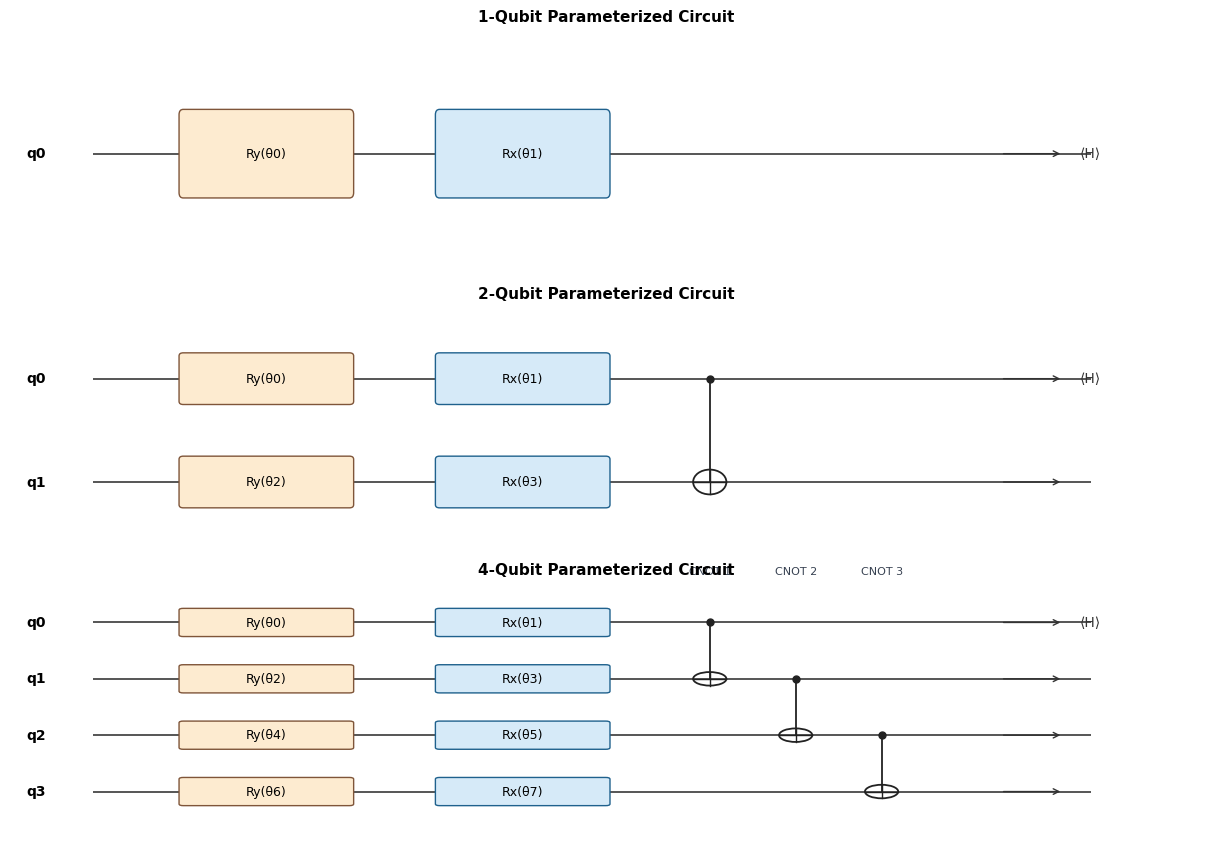

Parameter mapping examples:
- 1 qubit: [θ0, θ1] -> Ry(θ0), Rx(θ1)
- 2 qubits: [θ0, θ1, θ2, θ3] -> rotations on q0 and q1
- 4 qubits: [θ0..θ7] -> 2 rotations per qubit across q0..q3
- 4-qubit entangling sequence shown: CNOT(q0->q1), CNOT(q1->q2), CNOT(q2->q3)


In [9]:
def draw_param_circuit(ax, qubit_count):
    y_positions = list(range(qubit_count))[::-1]
    x_left, x_right = 0.6, 7.8

    ax.set_xlim(0, 8.6)
    ax.set_ylim(-0.7, qubit_count - 0.3)
    ax.axis("off")

    # Draw wires and qubit labels.
    for qi, y in enumerate(y_positions):
        ax.hlines(y, x_left, x_right, color="#555555", linewidth=1.4, zorder=1)
        ax.text(0.12, y, f"q{qi}", fontsize=10, va="center", fontweight="bold")

    # Draw rotation gates per qubit: Ry(theta_{2q}) then Rx(theta_{2q+1}).
    for qi, y in enumerate(y_positions):
        theta_ry = 2 * qi
        theta_rx = 2 * qi + 1

        ry_box = patches.FancyBboxPatch(
            (1.25, y - 0.22), 1.2, 0.44,
            boxstyle="round,pad=0.03", facecolor="#fdebd0", edgecolor="#7f5539", linewidth=1.0, zorder=3
        )
        rx_box = patches.FancyBboxPatch(
            (3.10, y - 0.22), 1.2, 0.44,
            boxstyle="round,pad=0.03", facecolor="#d6eaf8", edgecolor="#1f618d", linewidth=1.0, zorder=3
        )
        ax.add_patch(ry_box)
        ax.add_patch(rx_box)
        ax.text(1.85, y, f"Ry(θ{theta_ry})", ha="center", va="center", fontsize=9, zorder=4)
        ax.text(3.70, y, f"Rx(θ{theta_rx})", ha="center", va="center", fontsize=9, zorder=4)

    # Draw nearest-neighbor CNOT chain as a sequence in time (distinct x positions).
    if qubit_count > 1:
        cnot_start = 5.05
        cnot_step = 0.62

        for k in range(qubit_count - 1):
            x_cnot = cnot_start + k * cnot_step
            y_control = y_positions[k]
            y_target = y_positions[k + 1]

            ax.plot([x_cnot, x_cnot], [y_target, y_control], color="#222222", linewidth=1.3, zorder=2)
            ax.plot(x_cnot, y_control, marker="o", color="#222222", markersize=5, zorder=3)

            target_circle = patches.Circle((x_cnot, y_target), radius=0.12, fill=False, linewidth=1.3, edgecolor="#222222", zorder=3)
            ax.add_patch(target_circle)
            ax.plot([x_cnot - 0.12, x_cnot + 0.12], [y_target, y_target], color="#222222", linewidth=1.0, zorder=3)
            ax.plot([x_cnot, x_cnot], [y_target - 0.12, y_target + 0.12], color="#222222", linewidth=1.0, zorder=3)

            if qubit_count >= 3:
                ax.text(x_cnot, qubit_count - 0.18, f"CNOT {k+1}", ha="center", va="bottom", fontsize=8, color="#374151")

    # Measurement marker.
    for y in y_positions:
        ax.annotate("", xy=(7.6, y), xytext=(7.15, y), arrowprops=dict(arrowstyle="->", lw=1.0, color="#333333"), zorder=2)
    ax.text(7.72, y_positions[0], "⟨H⟩", fontsize=10, va="center", color="#333333")

    ax.set_title(f"{qubit_count}-Qubit Parameterized Circuit", fontsize=11, fontweight="bold")


fig, axes = plt.subplots(3, 1, figsize=(12, 8.3), constrained_layout=True)
for ax, q in zip(axes, [1, 2, 4]):
    draw_param_circuit(ax, qubit_count=q)
plt.show()

print("Parameter mapping examples:")
print("- 1 qubit: [θ0, θ1] -> Ry(θ0), Rx(θ1)")
print("- 2 qubits: [θ0, θ1, θ2, θ3] -> rotations on q0 and q1")
print("- 4 qubits: [θ0..θ7] -> 2 rotations per qubit across q0..q3")
print("- 4-qubit entangling sequence shown: CNOT(q0->q1), CNOT(q1->q2), CNOT(q2->q3)")

(sec-qml-visualization)=
## Network Visualization

This diagram shows the full data flow from image pixels -> classical layers -> quantum layer -> binary output.

The block heights encode feature-vector size, so you can see how dimensionality shrinks before reaching the quantum interface.

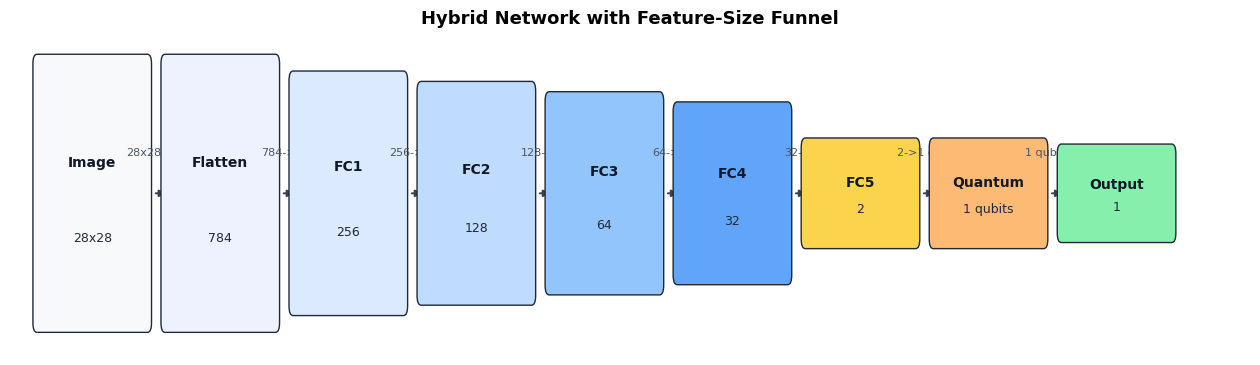

In [10]:
def draw_hybrid_architecture(qubit_count=QUBIT_COUNT):
    quantum_params = 2 * qubit_count

    stages = [
        ("Image", "28x28", 784, "#f8f9fa"),
        ("Flatten", "784", 784, "#eef2ff"),
        ("FC1", "256", 256, "#dbeafe"),
        ("FC2", "128", 128, "#bfdbfe"),
        ("FC3", "64", 64, "#93c5fd"),
        ("FC4", "32", 32, "#60a5fa"),
        ("FC5", f"{quantum_params}", max(quantum_params, 2), "#fcd34d"),
        ("Quantum", f"{qubit_count} qubits", max(qubit_count, 2), "#fdba74"),
        ("Output", "1", 1, "#86efac"),
    ]

    max_dim = max(s[2] for s in stages)

    fig, ax = plt.subplots(figsize=(16, 4.2))
    ax.set_xlim(0, len(stages) + 0.2)
    ax.set_ylim(0, 1)
    ax.axis("off")

    x = 0.2
    for i, (name, dim, size, color) in enumerate(stages):
        # Log-scaling so layer-height changes are visible but not extreme.
        h = 0.18 + 0.62 * (np.log2(size + 1) / np.log2(max_dim + 1))
        y = 0.5 - h / 2

        rect = patches.FancyBboxPatch(
            (x, y),
            0.82,
            h,
            boxstyle="round,pad=0.03,rounding_size=0.03",
            facecolor=color,
            edgecolor="#1f2937",
            linewidth=1.0,
            zorder=3,
        )
        ax.add_patch(rect)

        ax.text(x + 0.41, y + h * 0.62, name, ha="center", va="center", fontsize=10, fontweight="bold", color="#111827")
        ax.text(x + 0.41, y + h * 0.33, dim, ha="center", va="center", fontsize=9, color="#1f2937")

        if i < len(stages) - 1:
            ax.annotate(
                "",
                xy=(x + 0.98, 0.5),
                xytext=(x + 0.86, 0.5),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#374151"),
                zorder=2,
            )

            next_dim = stages[i + 1][1]
            ax.text(x + 0.92, 0.61, f"{dim}->{next_dim}", ha="center", va="bottom", fontsize=8, color="#4b5563")

        x += 0.95

    plt.title("Hybrid Network with Feature-Size Funnel", fontsize=13, fontweight="bold")
    plt.show()


draw_hybrid_architecture(QUBIT_COUNT)

(sec-qml-cpu)=
## CPU Run

[CPU quantum baseline] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz
[CPU quantum baseline] trainable parameters -> total=244258, trunk=244258, head=0
[CPU quantum baseline] quantum q=1 epoch   20/80 train acc=0.846 test acc=0.858
[CPU quantum baseline] quantum q=1 epoch   40/80 train acc=0.868 test acc=0.917
[CPU quantum baseline] quantum q=1 epoch   60/80 train acc=0.875 test acc=0.933
[CPU quantum baseline] quantum q=1 epoch   80/80 train acc=0.893 test acc=0.933


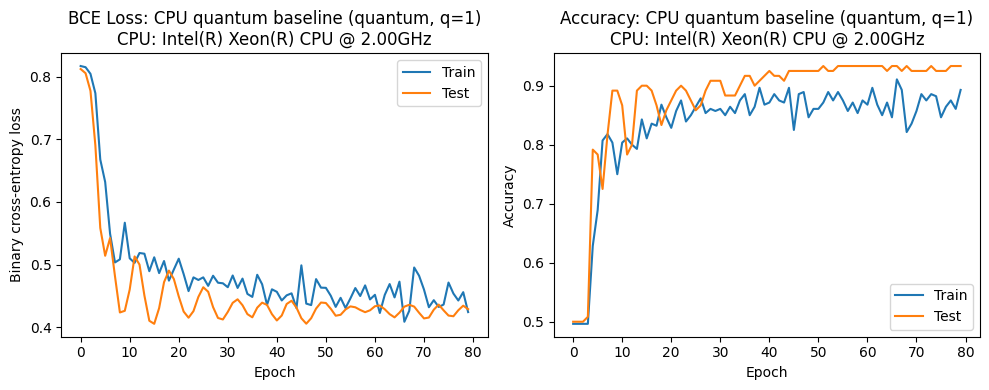

CPU elapsed time: 20.55 s


In [11]:
cpu_result = None

try:
    cpu_result = run_training(
        label="CPU quantum baseline",
        torch_device="cpu",
        qubit_count=QUBIT_COUNT,
        epochs=EPOCHS,
        seed=22,
        model_type="quantum",
        cudaq_target="qpp-cpu",
    )
    plot_history(cpu_result)
    print(f"CPU elapsed time: {cpu_result.elapsed_s:.2f} s")
except Exception as exc:
    print("CPU quantum run skipped:", exc)

(sec-qml-gpu)=
## GPU Run

Run this section after the CPU run. If no supported GPU backend is available, the cell will skip gracefully.

[GPU quantum baseline] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz | GPU=Tesla T4
[GPU quantum baseline] trainable parameters -> total=244258, trunk=244258, head=0
[GPU quantum baseline] quantum q=1 epoch   20/80 train acc=0.882 test acc=0.892
[GPU quantum baseline] quantum q=1 epoch   40/80 train acc=0.861 test acc=0.925
[GPU quantum baseline] quantum q=1 epoch   60/80 train acc=0.893 test acc=0.925
[GPU quantum baseline] quantum q=1 epoch   80/80 train acc=0.868 test acc=0.925


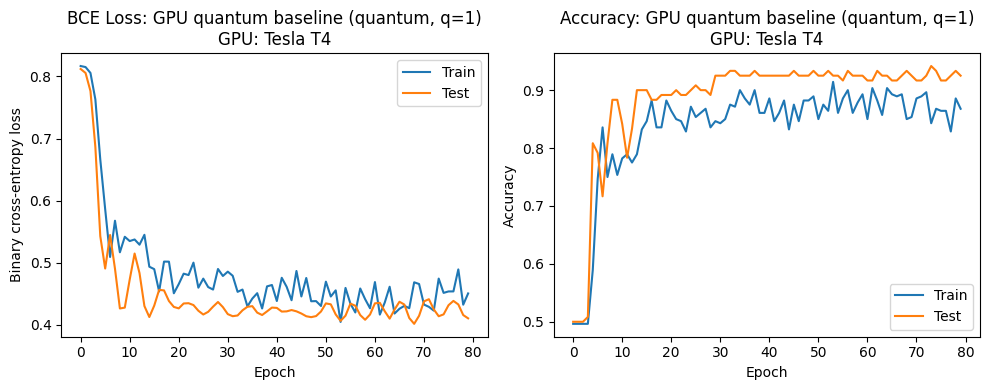

GPU elapsed time: 37.52 s


In [12]:
gpu_result = None

try:
    gpu_result = run_training(
        label="GPU quantum baseline",
        torch_device="cuda:0",
        qubit_count=QUBIT_COUNT,
        epochs=EPOCHS,
        seed=22,
        model_type="quantum",
        cudaq_target="nvidia",
    )
    plot_history(gpu_result)
    print(f"GPU elapsed time: {gpu_result.elapsed_s:.2f} s")
except Exception as exc:
    print("GPU run skipped:", exc)
    print("If you are in Colab, set Runtime -> Change runtime type -> GPU and rerun this cell.")

(sec-qml-classical)=
## Classical Parameter-Matched Baseline

This baseline replaces the quantum layer with a classical head having **exactly `2q` trainable weights**.

To avoid degenerate all-positive logits, the baseline uses signed trunk outputs before the matched head.
This keeps the head parameter count fixed at `2q` while allowing meaningful optimization.

[CPU classical matched] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz
[CPU classical matched] trainable parameters -> total=244260, trunk=244258, head=2
[CPU classical matched] classical q=1 epoch   20/80 train acc=0.957 test acc=0.958
[CPU classical matched] classical q=1 epoch   40/80 train acc=0.979 test acc=0.967
[CPU classical matched] classical q=1 epoch   60/80 train acc=0.979 test acc=0.967
[CPU classical matched] classical q=1 epoch   80/80 train acc=0.986 test acc=0.958


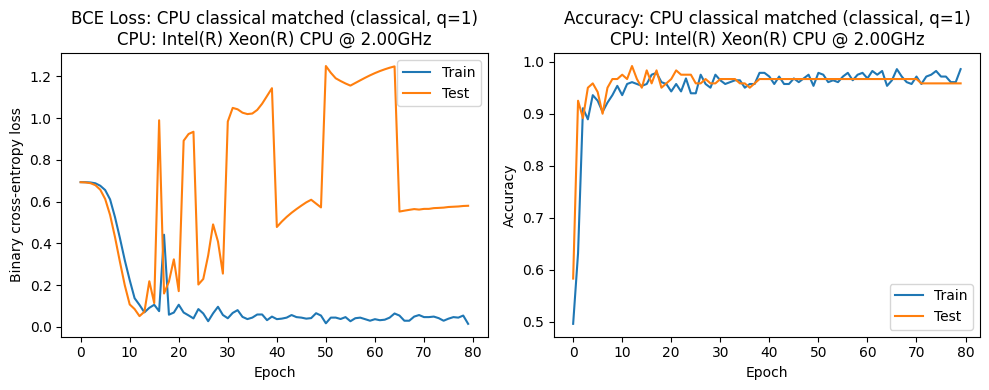

Classical baseline elapsed time: 0.98 s
Classical params (total/trunk/head): 244260/244258/2


In [13]:
classical_result = run_training(
    label="CPU classical matched",
    torch_device="cpu",
    qubit_count=QUBIT_COUNT,
    epochs=EPOCHS,
    seed=22,
    model_type="classical",
    cudaq_target=None,
)

plot_history(classical_result)
print(f"Classical baseline elapsed time: {classical_result.elapsed_s:.2f} s")
print(
    f"Classical params (total/trunk/head): "
    f"{classical_result.trainable_params_total}/"
    f"{classical_result.trainable_params_trunk}/"
    f"{classical_result.trainable_params_head}"
)

(sec-qml-compare)=
## Performance Comparison

Printed summaries and bar-plot labels include runtime hardware metadata so local vs Colab timing comparisons are reproducible.

Quantum vs classical-matched baselines:
- CPU quantum baseline   | model=quantum   | q=1 | target=qpp-cpu | device=cpu     | params=244258 (trunk=244258, head=0) | time=   20.55 s | test acc=0.933
  hardware: CPU=Intel(R) Xeon(R) CPU @ 2.00GHz
- GPU quantum baseline   | model=quantum   | q=1 | target=nvidia  | device=cuda:0  | params=244258 (trunk=244258, head=0) | time=   37.52 s | test acc=0.925
  hardware: CPU=Intel(R) Xeon(R) CPU @ 2.00GHz | GPU=Tesla T4
- CPU classical matched  | model=classical | q=1 | target=none    | device=cpu     | params=244260 (trunk=244258, head=2) | time=    0.98 s | test acc=0.958
  hardware: CPU=Intel(R) Xeon(R) CPU @ 2.00GHz


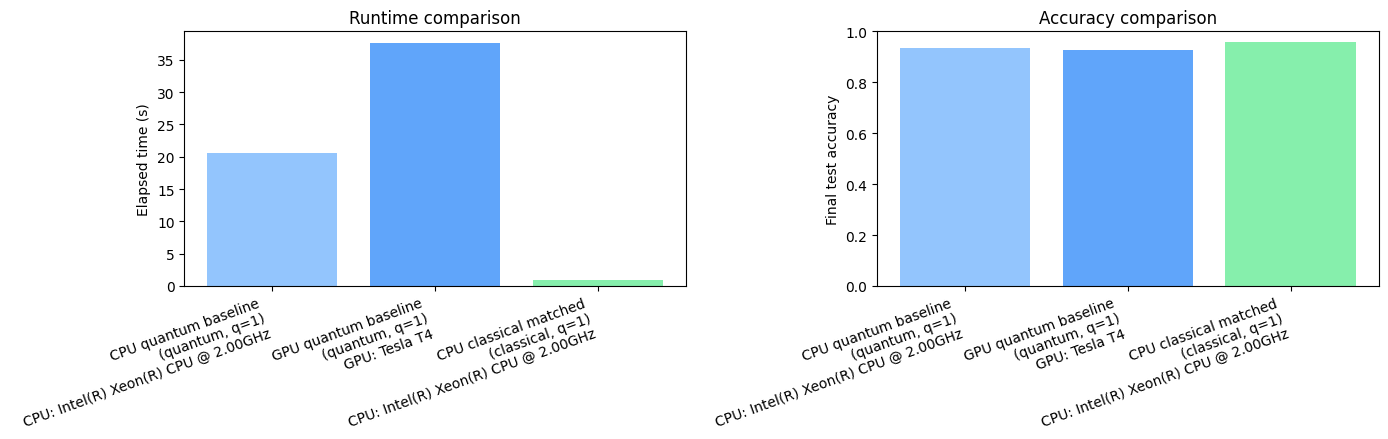

In [14]:
def summarize_runs(results, title="Completed runs"):
    if not results:
        print("No completed runs to compare.")
        return

    print(title + ":")
    for result in results:
        print(
            f"- {result.label:22s} | model={result.model_type:9s} | q={result.qubit_count} | "
            f"target={result.cudaq_target:7s} | device={result.device_name:7s} | "
            f"params={result.trainable_params_total} (trunk={result.trainable_params_trunk}, head={result.trainable_params_head}) | "
            f"time={result.elapsed_s:8.2f} s | test acc={result.final_test_accuracy:.3f}"
        )
        print(f"  hardware: {result.hardware_full}")


def plot_run_comparison(results):
    if len(results) < 2:
        print("Need at least two completed runs for a side-by-side plot.")
        return

    labels = [
        f"{r.label}\n({r.model_type}, q={r.qubit_count})\n{r.hardware_short}"
        for r in results
    ]
    times = [r.elapsed_s for r in results]
    accuracies = [r.final_test_accuracy for r in results]

    plt.figure(figsize=(14, 4.5))

    plt.subplot(1, 2, 1)
    plt.bar(labels, times, color=["#93c5fd", "#60a5fa", "#86efac"][:len(labels)])
    plt.ylabel("Elapsed time (s)")
    plt.title("Runtime comparison")
    plt.xticks(rotation=20, ha="right")

    plt.subplot(1, 2, 2)
    plt.bar(labels, accuracies, color=["#93c5fd", "#60a5fa", "#86efac"][:len(labels)])
    plt.ylabel("Final test accuracy")
    plt.ylim(0, 1)
    plt.title("Accuracy comparison")
    plt.xticks(rotation=20, ha="right")

    plt.tight_layout()
    plt.show()


baseline_results = [result for result in [cpu_result, gpu_result, classical_result] if result is not None]
summarize_runs(baseline_results, title="Quantum vs classical-matched baselines")
plot_run_comparison(baseline_results)

(sec-qml-difficulty)=
## Is This Dataset Too Easy?

This is a fair concern. High accuracies here are expected because this notebook is a **binary** task (digits 5 vs 6) with a relatively strong classical trunk.

So this example is best interpreted as:
- a demonstration of hybrid QNN workflow and scaling behavior,
- not a definitive benchmark of quantum advantage.

To make the learning problem harder, you can try:
- more confusable pairs (e.g., 3 vs 5, 4 vs 9),
- multiclass classification,
- lower sample counts with stronger regularization,
- added noise/rotations/occlusions in input images.

(sec-qml-scaling)=
## Qubit Scaling Study

We evaluate a small qubit range to see how runtime and final test accuracy scale for the **quantum model**.

To avoid redundant work, the sweep **reuses the baseline q=1 result** when available and only trains missing qubit values.
Because `SWEEP_EPOCHS` is set to `EPOCHS` by default, the reused baseline is directly comparable to sweep runs.

We also report trainable parameter counts so you can verify growth with qubit count.

(sec-qml-param-scaling)=
### Parameter Count Check

Before running the qubit sweep, we explicitly verify trainable parameter growth with qubit count.
This confirms that increasing qubits increases model parameters in this architecture.

In [15]:
def report_parameter_counts(qubit_values):
    cpu_name = read_cpu_name()
    print("Parameter counts by qubit count (CPU model construction):")
    print(f"CPU used for count report: {cpu_name}")

    for q in qubit_values:
        # Quantum model has no trainable head parameters in this implementation,
        # so we can report trainable counts from the trunk even if CUDA-Q is unavailable.
        quantum_trunk = HybridTrunk(q, use_final_relu=True)
        q_total = count_trainable_params(quantum_trunk)
        q_trunk = q_total
        q_head = 0

        classical_model = HybridClassicalBaseline(q)
        c_total = count_trainable_params(classical_model)
        c_trunk = count_trainable_params(classical_model.trunk)
        c_head = count_trainable_params(classical_model.classical_head)

        print(
            f"q={q}: quantum total/trunk/head = {q_total}/{q_trunk}/{q_head} | "
            f"classical total/trunk/head = {c_total}/{c_trunk}/{c_head}"
        )


report_parameter_counts(QUBIT_VALUES_TO_TEST)

Parameter counts by qubit count (CPU model construction):
CPU used for count report: Intel(R) Xeon(R) CPU @ 2.00GHz
q=1: quantum total/trunk/head = 244258/244258/0 | classical total/trunk/head = 244260/244258/2
q=2: quantum total/trunk/head = 244324/244324/0 | classical total/trunk/head = 244328/244324/4
q=4: quantum total/trunk/head = 244456/244456/0 | classical total/trunk/head = 244464/244456/8


In [16]:
cpu_qubit_sweep = []

if not CUDAQ_AVAILABLE:
    print("Skipping CPU quantum sweep because CUDA-Q is unavailable in this runtime.")
else:
    if cpu_result is not None and cpu_result.model_type == "quantum" and cpu_result.qubit_count in QUBIT_VALUES_TO_TEST:
        print(f"Reusing CPU baseline result for q={cpu_result.qubit_count} in the sweep.")
        cpu_qubit_sweep.append(cpu_result)

    for q in QUBIT_VALUES_TO_TEST:
        if any(r.qubit_count == q for r in cpu_qubit_sweep):
            continue

        result = run_training(
            label="CPU quantum sweep",
            torch_device="cpu",
            qubit_count=q,
            epochs=SWEEP_EPOCHS,
            log_every=max(10, SWEEP_EPOCHS // 5),
            seed=22,
            model_type="quantum",
            cudaq_target="qpp-cpu",
        )
        cpu_qubit_sweep.append(result)

    cpu_qubit_sweep = sorted(cpu_qubit_sweep, key=lambda r: r.qubit_count)
    summarize_runs(cpu_qubit_sweep, title="CPU qubit sweep")

Reusing CPU baseline result for q=1 in the sweep.
[CPU quantum sweep] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz
[CPU quantum sweep] trainable parameters -> total=244324, trunk=244324, head=0
[CPU quantum sweep] quantum q=2 epoch   16/80 train acc=0.839 test acc=0.883
[CPU quantum sweep] quantum q=2 epoch   32/80 train acc=0.846 test acc=0.867
[CPU quantum sweep] quantum q=2 epoch   48/80 train acc=0.907 test acc=0.900
[CPU quantum sweep] quantum q=2 epoch   64/80 train acc=0.896 test acc=0.892
[CPU quantum sweep] quantum q=2 epoch   80/80 train acc=0.882 test acc=0.942
[CPU quantum sweep] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz
[CPU quantum sweep] trainable parameters -> total=244456, trunk=244456, head=0
[CPU quantum sweep] quantum q=4 epoch   16/80 train acc=0.843 test acc=0.892
[CPU quantum sweep] quantum q=4 epoch   32/80 train acc=0.886 test acc=0.933
[CPU quantum sweep] quantum q=4 epoch   48/80 train acc=0.896 test acc=0.933
[CPU quantum sweep] quantu

In [17]:
gpu_qubit_sweep = []

if not CUDAQ_AVAILABLE:
    print("Skipping GPU quantum sweep because CUDA-Q is unavailable in this runtime.")
else:
    if gpu_result is not None and gpu_result.model_type == "quantum" and gpu_result.qubit_count in QUBIT_VALUES_TO_TEST:
        print(f"Reusing GPU baseline result for q={gpu_result.qubit_count} in the sweep.")
        gpu_qubit_sweep.append(gpu_result)

    if RUN_GPU_SWEEP:
        for q in QUBIT_VALUES_TO_TEST:
            if any(r.qubit_count == q for r in gpu_qubit_sweep):
                continue

            try:
                result = run_training(
                    label="GPU quantum sweep",
                    torch_device="cuda:0",
                    qubit_count=q,
                    epochs=SWEEP_EPOCHS,
                    log_every=max(10, SWEEP_EPOCHS // 5),
                    seed=22,
                    model_type="quantum",
                    cudaq_target="nvidia",
                )
                gpu_qubit_sweep.append(result)
            except Exception as exc:
                print(f"Skipping GPU sweep for q={q}: {exc}")
                break

        gpu_qubit_sweep = sorted(gpu_qubit_sweep, key=lambda r: r.qubit_count)

        if gpu_qubit_sweep:
            summarize_runs(gpu_qubit_sweep, title="GPU qubit sweep")
    else:
        print("GPU qubit sweep skipped (RUN_GPU_SWEEP = False).")

Reusing GPU baseline result for q=1 in the sweep.
[GPU quantum sweep] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz | GPU=Tesla T4
[GPU quantum sweep] trainable parameters -> total=244324, trunk=244324, head=0
[GPU quantum sweep] quantum q=2 epoch   16/80 train acc=0.854 test acc=0.883
[GPU quantum sweep] quantum q=2 epoch   32/80 train acc=0.857 test acc=0.892
[GPU quantum sweep] quantum q=2 epoch   48/80 train acc=0.889 test acc=0.925
[GPU quantum sweep] quantum q=2 epoch   64/80 train acc=0.868 test acc=0.883
[GPU quantum sweep] quantum q=2 epoch   80/80 train acc=0.882 test acc=0.892
[GPU quantum sweep] runtime hardware -> CPU=Intel(R) Xeon(R) CPU @ 2.00GHz | GPU=Tesla T4
[GPU quantum sweep] trainable parameters -> total=244456, trunk=244456, head=0
[GPU quantum sweep] quantum q=4 epoch   16/80 train acc=0.786 test acc=0.917
[GPU quantum sweep] quantum q=4 epoch   32/80 train acc=0.850 test acc=0.933
[GPU quantum sweep] quantum q=4 epoch   48/80 train acc=0.854 test acc=0.

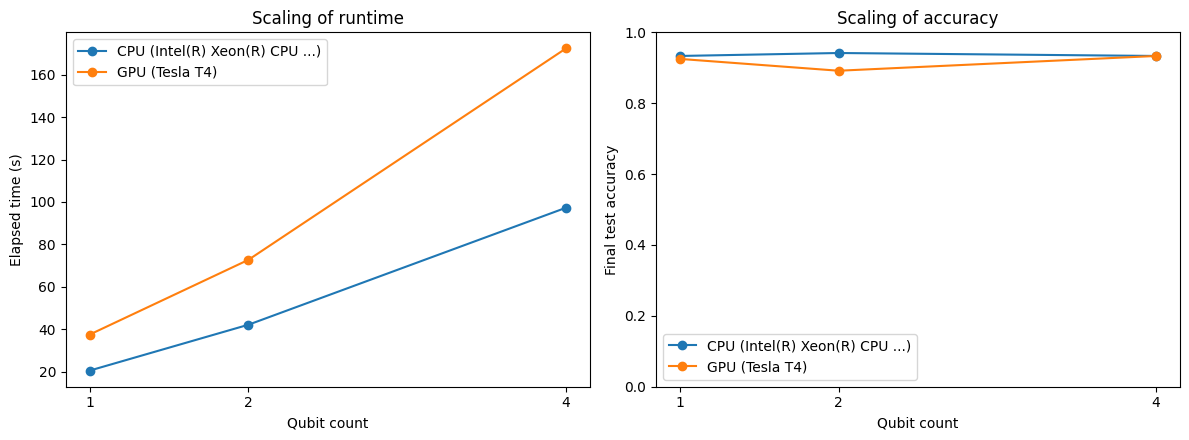

In [18]:
def plot_qubit_scaling(cpu_results, gpu_results):
    if not cpu_results and not gpu_results:
        print("No sweep results to plot.")
        return

    plt.figure(figsize=(12, 4.5))

    plt.subplot(1, 2, 1)
    x_values_runtime = []
    if cpu_results:
        q_cpu = [r.qubit_count for r in cpu_results]
        t_cpu = [r.elapsed_s for r in cpu_results]
        cpu_label = f"CPU ({compact_name(cpu_results[0].cpu_name, 24)})"
        plt.plot(q_cpu, t_cpu, marker="o", label=cpu_label)
        x_values_runtime.extend(q_cpu)
    if gpu_results:
        q_gpu = [r.qubit_count for r in gpu_results]
        t_gpu = [r.elapsed_s for r in gpu_results]
        gpu_name = gpu_results[0].gpu_name if gpu_results[0].gpu_name != "none" else "unknown-gpu"
        gpu_label = f"GPU ({compact_name(gpu_name, 24)})"
        plt.plot(q_gpu, t_gpu, marker="o", label=gpu_label)
        x_values_runtime.extend(q_gpu)
    if x_values_runtime:
        plt.xticks(sorted(set(x_values_runtime)))
    plt.xlabel("Qubit count")
    plt.ylabel("Elapsed time (s)")
    plt.title("Scaling of runtime")
    plt.legend()

    plt.subplot(1, 2, 2)
    x_values_acc = []
    if cpu_results:
        q_cpu = [r.qubit_count for r in cpu_results]
        a_cpu = [r.final_test_accuracy for r in cpu_results]
        cpu_label = f"CPU ({compact_name(cpu_results[0].cpu_name, 24)})"
        plt.plot(q_cpu, a_cpu, marker="o", label=cpu_label)
        x_values_acc.extend(q_cpu)
    if gpu_results:
        q_gpu = [r.qubit_count for r in gpu_results]
        a_gpu = [r.final_test_accuracy for r in gpu_results]
        gpu_name = gpu_results[0].gpu_name if gpu_results[0].gpu_name != "none" else "unknown-gpu"
        gpu_label = f"GPU ({compact_name(gpu_name, 24)})"
        plt.plot(q_gpu, a_gpu, marker="o", label=gpu_label)
        x_values_acc.extend(q_gpu)
    if x_values_acc:
        plt.xticks(sorted(set(x_values_acc)))
    plt.xlabel("Qubit count")
    plt.ylabel("Final test accuracy")
    plt.ylim(0, 1)
    plt.title("Scaling of accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_qubit_scaling(cpu_qubit_sweep, gpu_qubit_sweep)

(sec-qml-references)=
## References

Foundational and useful references for QNNs and quantum ML:

- Farhi, E., and Neven, H. (2018). *Classification with Quantum Neural Networks on Near Term Processors.* [arXiv:1802.06002](https://arxiv.org/abs/1802.06002)
- Biamonte, J., et al. (2017). *Quantum machine learning.* Nature 549, 195-202. [https://doi.org/10.1038/nature23474](https://doi.org/10.1038/nature23474)
- Schuld, M., and Killoran, N. (2019). *Quantum machine learning in feature Hilbert spaces.* Phys. Rev. Lett. 122, 040504. [https://doi.org/10.1103/PhysRevLett.122.040504](https://doi.org/10.1103/PhysRevLett.122.040504)
- Abbas, A., et al. (2021). *The power of quantum neural networks.* Nature Computational Science 1, 403-409. [https://doi.org/10.1038/s43588-021-00084-1](https://doi.org/10.1038/s43588-021-00084-1)
- Cerezo, M., et al. (2021). *Variational quantum algorithms.* Nature Reviews Physics 3, 625-644. [https://doi.org/10.1038/s42254-021-00348-9](https://doi.org/10.1038/s42254-021-00348-9)
- NVIDIA CUDA-Q tutorial used as starting point for this lecture: [Hybrid QNNs](https://nvidia.github.io/cuda-quantum/0.8.0/examples/python/tutorials/hybrid_qnns.html)

Practical modeling note:
- always compare against parameter-matched classical baselines when assessing hybrid QNN performance.

### Check Your Understanding
- Write a 1-qubit state as a linear combination of `|0>` and `|1>`, and explain what the squared magnitudes mean.
- In your own words, what does changing `theta` in `Rx(theta)` or `Ry(theta)` do to the qubit state?
- Use the CNOT truth table to explain why `(|00> + |10>)/sqrt(2)` becomes an entangled state after CNOT.
- For `q=4`, how many rotation parameters are used in this ansatz, and where do they come from in the hybrid model?